<a href="https://colab.research.google.com/github/AffazHussain/S-C-O-P-E/blob/main/ScopeAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import requests

# The API URL that fetches the exoplanet data
api_url = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync?query=select+pl_name,pl_masse,pl_rade,pl_orbper,discoverymethod,sy_snum,sy_pnum,disc_year+from+pscomppars&format=json"

print("Fetching data from NASA Exoplanet Archive...")

# Use the requests library to get data from the URL
response = requests.get(api_url)

# Check if the request was successful
if response.status_code == 200:
    # Convert the JSON response into a Python list of dictionaries
    data = response.json()

    # Convert the list of dictionaries into a pandas DataFrame
    df = pd.DataFrame(data)

    print("Data fetched successfully! ✅")
    print(f"Loaded {len(df)} exoplanets into the DataFrame.")

    # Display the first 5 rows of your new DataFrame to verify
    print("\nHere's a preview of your data:")
    display(df.head())

else:
    print(f"Failed to fetch data. Status code: {response.status_code}")

Fetching data from NASA Exoplanet Archive...
Data fetched successfully! ✅
Loaded 6052 exoplanets into the DataFrame.

Here's a preview of your data:


,pl_name,pl_masse,pl_rade,pl_orbper,discoverymethod,sy_snum,sy_pnum,disc_year
0,Kepler-1167 b,NaN,1.710000,1.003934,Transit,1,1,2016
1,Kepler-1740 b,NaN,3.323214,8.172400,Transit,1,1,2021
2,Kepler-1581 b,NaN,0.800000,6.283855,Transit,1,1,2016
3,Kepler-644 b,NaN,3.150000,3.173917,Transit,1,1,2016
4,Kepler-1752 b,NaN,4.540605,56.358501,Transit,1,1,2021


In [2]:
# This will count the number of NaN values in every column
df.isnull().sum()


,0
pl_name,0
pl_masse,3802
pl_rade,25
pl_orbper,315
discoverymethod,0
sy_snum,0
sy_pnum,0
disc_year,0


In [3]:
# Calculate the medians first
median_mass = df['pl_masse'].median()
median_radius = df['pl_rade'].median()
median_orbper = df['pl_orbper'].median()

# Assign the filled Series back to the column
df['pl_masse'] = df['pl_masse'].fillna(median_mass)
df['pl_rade'] = df['pl_rade'].fillna(median_radius)
df['pl_orbper'] = df['pl_orbper'].fillna(median_orbper)

print("Missing values handled without warnings.")

Missing values handled without warnings.


In [4]:
# Verify that all missing values in these columns are handled
print("\nMissing values after cleaning:")
df[['pl_masse', 'pl_rade', 'pl_orbper']].isnull().sum()


Missing values after cleaning:


,0
pl_masse,0
pl_rade,0
pl_orbper,0


In [5]:
# This provides a statistical summary of the numerical columns
df.describe()

,pl_masse,pl_rade,pl_orbper,sy_snum,sy_pnum,disc_year
count,6052.000000,6052.000000,6.052000e+03,6052.000000,6052.000000,6052.000000
mean,387.088780,5.797425,7.071160e+04,1.104594,1.771315,2016.847819
std,989.364205,5.335802,5.169873e+06,0.345137,1.159948,4.887984
min,0.020000,0.309800,9.070629e-02,1.000000,1.000000,1992.000000
25%,154.941348,1.827260,4.574292e+00,1.000000,1.000000,2014.000000
50%,154.941348,2.830000,1.111991e+01,1.000000,1.000000,2016.000000
75%,154.941348,11.900989,3.569105e+01,1.000000,2.000000,2021.000000
max,9344.155166,77.342100,4.020000e+08,4.000000,8.000000,2025.000000


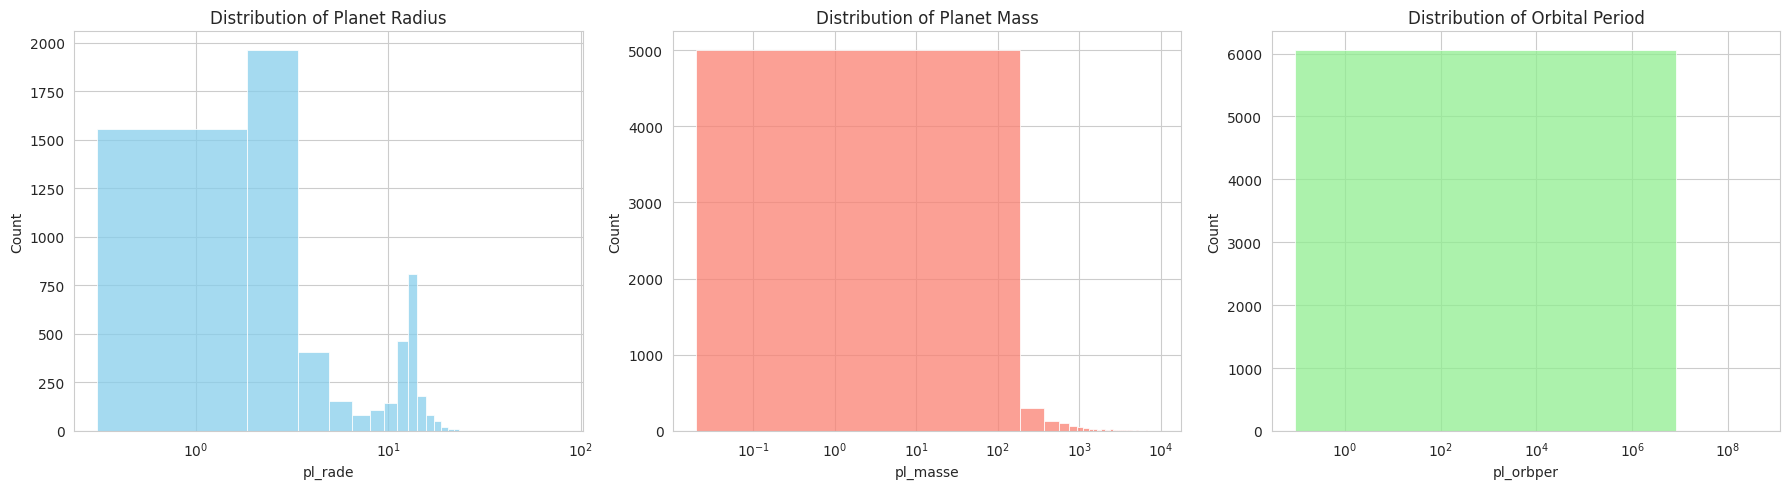

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional style for the plots
sns.set_style("whitegrid")

# Create a figure to hold multiple plots
plt.figure(figsize=(18, 5))

# Plot 1: Distribution of Planet Radius
plt.subplot(1, 3, 1) # (1 row, 3 columns, 1st plot)
sns.histplot(df['pl_rade'], bins=50, color='skyblue')
plt.title('Distribution of Planet Radius')
plt.xscale('log') # Use a log scale because of the huge range

# Plot 2: Distribution of Planet Mass
plt.subplot(1, 3, 2)
sns.histplot(df['pl_masse'], bins=50, color='salmon')
plt.title('Distribution of Planet Mass')
plt.xscale('log')

# Plot 3: Distribution of Orbital Period
plt.subplot(1, 3, 3)
sns.histplot(df['pl_orbper'], bins=50, color='lightgreen')
plt.title('Distribution of Orbital Period')
plt.xscale('log')

plt.tight_layout() # Adjusts plots to prevent overlap
plt.show()

In [7]:
import numpy as np

# A simple rule: a planet is a candidate if its radius is between 0.8 and 1.9 Earths.
df['habitable_candidate'] = np.where(
    (df['pl_rade'] >= 0.8) & (df['pl_rade'] <= 1.9),
    1,  # 1 means YES
    0   # 0 means NO
)

# Now, select the features (clues) the model will use to predict the target
features = ['pl_masse', 'pl_rade', 'pl_orbper', 'sy_snum', 'sy_pnum']
target = 'habitable_candidate'

X = df[features]
y = df[target]

print("Target variable 'habitable_candidate' created.")
print(y.value_counts())

Target variable 'habitable_candidate' created.
habitable_candidate
0    4515
1    1537
Name: count, dtype: int64


In [8]:
from sklearn.model_selection import train_test_split

# Split data into 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,     # 20% of data goes to the test set
    random_state=42,   # Ensures the split is the same every time you run
    stratify=y         # Ensures train and test sets have a similar proportion of candidates
)

print(f"Data successfully split:")
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Data successfully split:
Training features shape: (4841, 5)
Testing features shape: (1211, 5)


In [9]:
from sklearn.ensemble import RandomForestClassifier

# 1. Create the model
# n_estimators=100 means it will build 100 decision trees.
# random_state=42 ensures you get the same result every time you run.
model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train the model using your training data
print("Training the Random Forest model...")
model.fit(X_train, y_train)

print("Model training complete! ✅")

Training the Random Forest model...
Model training complete! ✅


In [10]:
# Use the trained model to make predictions on the test set
y_pred = model.predict(X_test)

print("Predictions made on the test data.")

Predictions made on the test data.


In [11]:
from sklearn.metrics import accuracy_score, classification_report

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

# Print a more detailed report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Candidate (0)', 'Candidate (1)']))

Model Accuracy: 100.00%

Classification Report:
                   precision    recall  f1-score   support

Not Candidate (0)       1.00      1.00      1.00       903
    Candidate (1)       1.00      1.00      1.00       308

         accuracy                           1.00      1211
        macro avg       1.00      1.00      1.00      1211
     weighted avg       1.00      1.00      1.00      1211



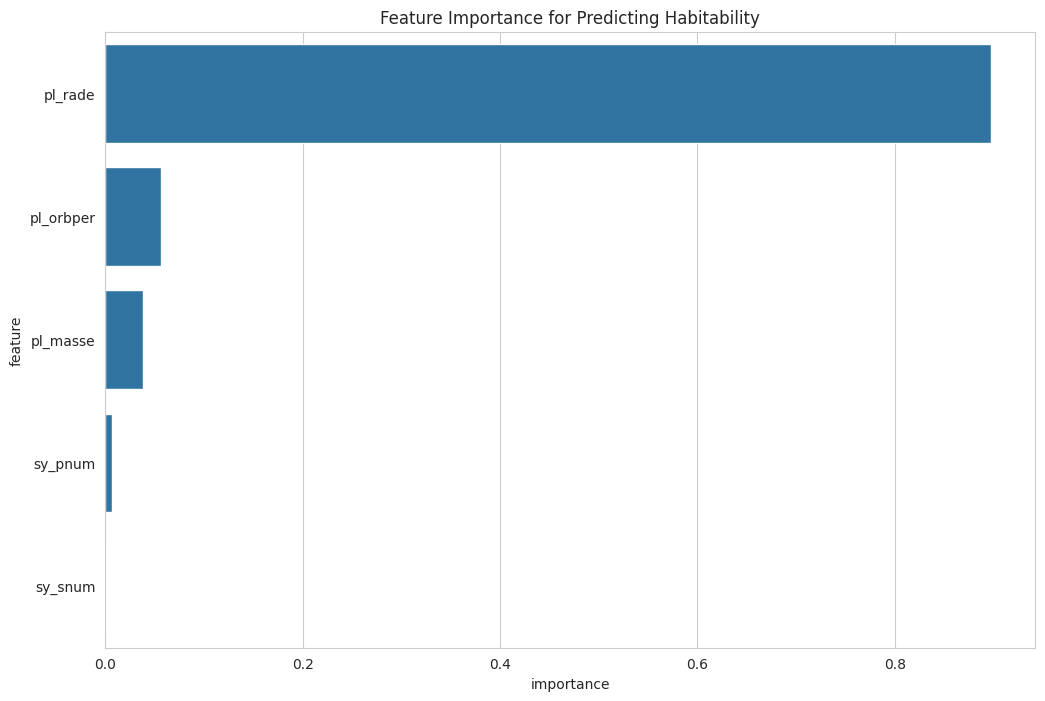

In [12]:
# Get the importance of each feature from the trained model
importances = model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importance_df)
plt.title('Feature Importance for Predicting Habitability')
plt.show()

In [13]:
# Get the feature names from your training columns
feature_names = X_train.columns

# Create a new planet's data as a DataFrame with column names
new_planet_df = pd.DataFrame([[1.1, 1.2, 300, 1, 3]], columns=feature_names)

# Use the DataFrame to make a prediction
prediction = model.predict(new_planet_df)

if prediction[0] == 1:
    print("Prediction for the new planet: It IS a habitable candidate! ✅")
else:
    print("Prediction for the new planet: It is NOT a habitable candidate. ❌")

Prediction for the new planet: It IS a habitable candidate! ✅


In [14]:
# -------------------------
# Robust Scientific HZ block
# Paste this after the cell that defines `df`
# -------------------------
import numpy as np
import pandas as pd
import requests
import math
import warnings
warnings.filterwarnings("ignore")

# Safety: ensure df exists
if "df" not in globals():
    raise ValueError("❌ 'df' not found. Run the cell that fetches the NASA data first.")

print("Running robust scientific habitability calculations...")

# Fetch extra columns from NASA (safe)
extra_api_url = (
    "https://exoplanetarchive.ipac.caltech.edu/TAP/sync?"
    "query=select+pl_name,pl_orbsmax,pl_orbper,pl_insol,st_teff,st_rad,st_mass+from+pscomppars&format=json"
)
extra_res = requests.get(extra_api_url, timeout=60)
extra_df = pd.DataFrame(extra_res.json())

# Merge on pl_name (safe join)
df = df.merge(extra_df, on="pl_name", how="left", suffixes=("", "_new"))

# Utility: find available column by trying candidates
def find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

# Candidate names to look for (accounting for possible suffixing)
col_map = {
    "pl_orbsmax": find_col(df, ["pl_orbsmax", "pl_orbsmax_new"]),
    "pl_orbper":  find_col(df, ["pl_orbper", "pl_orbper_new", "pl_orbper_x", "pl_orbper_y"]),
    "pl_insol":   find_col(df, ["pl_insol", "pl_insol_new"]),
    "st_teff":    find_col(df, ["st_teff", "st_teff_new", "st_teff_x", "st_teff_y"]),
    "st_rad":     find_col(df, ["st_rad", "st_rad_new", "st_rad_x", "st_rad_y"]),
    "st_mass":    find_col(df, ["st_mass", "st_mass_new", "st_mass_x", "st_mass_y"])
}

print("Detected columns used for calculations:")
for k, v in col_map.items():
    print(f"  {k} -> {v}")

# Convert detected columns to numeric (create columns even if missing)
for out_col, detected in col_map.items():
    if detected is not None:
        df[out_col] = pd.to_numeric(df[detected], errors="coerce")
    else:
        df[out_col] = np.nan

# ----------------------------------------------------------------
# 1) Stellar luminosity (relative to Sun) via Stefan-Boltzmann
#    L/L_sun = (R/R_sun)^2 * (T/T_sun)^4
# ----------------------------------------------------------------
T_sun = 5772.0
df["stellar_luminosity"] = np.where(
    (~df["st_rad"].isna()) & (~df["st_teff"].isna()),
    (df["st_rad"] ** 2) * ((df["st_teff"] / T_sun) ** 4),
    np.nan
)

# ----------------------------------------------------------------
# 2) Semi-major axis (AU): use pl_orbsmax if present; else compute from period + stellar mass
#    Kepler: a^3 = G M_star P^2 / (4 pi^2)
# ----------------------------------------------------------------
G = 6.67430e-11
M_sun = 1.98847e30
AU_m = 1.495978707e11

def compute_semi_major_a(row):
    # If pl_orbsmax exists and is finite, use it (already in AU)
    if not pd.isna(row["pl_orbsmax"]):
        return row["pl_orbsmax"]
    # else try period + stellar mass
    P_days = row["pl_orbper"]
    M_star_sun = row["st_mass"]
    if pd.isna(P_days) or pd.isna(M_star_sun) or M_star_sun <= 0:
        return np.nan
    # Convert to SI
    P_sec = P_days * 24.0 * 3600.0
    M_star_kg = M_star_sun * M_sun
    try:
        a_m = ((G * M_star_kg * P_sec**2) / (4.0 * math.pi**2)) ** (1.0 / 3.0)
        return a_m / AU_m
    except Exception:
        return np.nan

# Apply compute function
df["semi_major_axis_AU"] = df.apply(compute_semi_major_a, axis=1)

# ----------------------------------------------------------------
# 3) Insolation (Earth units) S = L_rel / a^2
# ----------------------------------------------------------------
df["insolation_calc"] = np.where(
    (~df["stellar_luminosity"].isna()) & (~df["semi_major_axis_AU"].isna()) & (df["semi_major_axis_AU"] > 0),
    df["stellar_luminosity"] / (df["semi_major_axis_AU"] ** 2),
    np.nan
)

# If reported pl_insol exists, keep it in a column to compare
if col_map["pl_insol"] is not None:
    df["pl_insol_reported"] = pd.to_numeric(df[col_map["pl_insol"]], errors="coerce")
else:
    df["pl_insol_reported"] = np.nan

# ----------------------------------------------------------------
# 4) Habitable Zone bounds (Kopparapu conservative & optimistic S_eff values)
# Conservative (common approximation): inner ~1.04, outer ~0.35
# Optimistic (recent Venus / early Mars): inner ~1.78, outer ~0.32
# ----------------------------------------------------------------
Seff_cons_inner = 1.04
Seff_cons_outer = 0.35
Seff_opt_inner = 1.78
Seff_opt_outer = 0.32

df["hz_cons_inner_AU"] = np.where(~df["stellar_luminosity"].isna(), np.sqrt(df["stellar_luminosity"] / Seff_cons_inner), np.nan)
df["hz_cons_outer_AU"] = np.where(~df["stellar_luminosity"].isna(), np.sqrt(df["stellar_luminosity"] / Seff_cons_outer), np.nan)
df["hz_opt_inner_AU"] = np.where(~df["stellar_luminosity"].isna(), np.sqrt(df["stellar_luminosity"] / Seff_opt_inner), np.nan)
df["hz_opt_outer_AU"] = np.where(~df["stellar_luminosity"].isna(), np.sqrt(df["stellar_luminosity"] / Seff_opt_outer), np.nan)

# Flags: is planet inside HZ?
df["in_hz_conservative"] = np.where(
    (~df["semi_major_axis_AU"].isna()) & (~df["hz_cons_inner_AU"].isna()) & (~df["hz_cons_outer_AU"].isna()) &
    (df["semi_major_axis_AU"] >= df["hz_cons_inner_AU"]) & (df["semi_major_axis_AU"] <= df["hz_cons_outer_AU"]),
    True, False
)

df["in_hz_optimistic"] = np.where(
    (~df["semi_major_axis_AU"].isna()) & (~df["hz_opt_inner_AU"].isna()) & (~df["hz_opt_outer_AU"].isna()) &
    (df["semi_major_axis_AU"] >= df["hz_opt_inner_AU"]) & (df["semi_major_axis_AU"] <= df["hz_opt_outer_AU"]),
    True, False
)

# ----------------------------------------------------------------
# 5) Add scientific habitability column (binary) — conservative criterion
# ----------------------------------------------------------------
df["habitable_candidate_scientific"] = df["in_hz_conservative"].astype(int)

print("\nSummary (n rows):", len(df))
print("Number planets flagged inside conservative HZ:", int(df["habitable_candidate_scientific"].sum()))
print("Number planets flagged inside optimistic HZ:", int(df["in_hz_optimistic"].sum()))

# Show first few rows with key columns for verification
display_cols = [
    "pl_name", "semi_major_axis_AU", "pl_orbsmax", "pl_orbper",
    "st_mass", "st_rad", "st_teff", "stellar_luminosity",
    "insolation_calc", "pl_insol_reported",
    "hz_cons_inner_AU", "hz_cons_outer_AU",
    "in_hz_conservative", "in_hz_optimistic", "habitable_candidate_scientific"
]
existing_display_cols = [c for c in display_cols if c in df.columns]
print("\nPreview of computed columns:")
display(df[existing_display_cols].head(12))

# Optional: inspect rows with large disagreement between reported and calculated insolation
if df["pl_insol_reported"].notna().any():
    df["insol_pct_diff"] = np.nan
    mask = df["pl_insol_reported"].notna() & df["insolation_calc"].notna() & (df["pl_insol_reported"] != 0)
    df.loc[mask, "insol_pct_diff"] = 100.0 * (df.loc[mask, "insolation_calc"] - df.loc[mask, "pl_insol_reported"]) / df.loc[mask, "pl_insol_reported"]
    # show large diffs
    large_diff = df[mask & (df["insol_pct_diff"].abs() > 200)].sort_values("insol_pct_diff", ascending=False)
    if not large_diff.empty:
        print("\nRows with >200% difference between reported and calculated insolation (sample):")
        display(large_diff[existing_display_cols + ["insol_pct_diff"]].head(10))

print("\nDone. You can now replace your ML target with 'habitable_candidate_scientific' if you want a physics-based target.")

Running robust scientific habitability calculations...
Detected columns used for calculations:
  pl_orbsmax -> pl_orbsmax
  pl_orbper -> pl_orbper
  pl_insol -> pl_insol
  st_teff -> st_teff
  st_rad -> st_rad
  st_mass -> st_mass

Summary (n rows): 6052
Number planets flagged inside conservative HZ: 171
Number planets flagged inside optimistic HZ: 297

Preview of computed columns:


,pl_name,semi_major_axis_AU,pl_orbsmax,pl_orbper,st_mass,st_rad,st_teff,stellar_luminosity,insolation_calc,pl_insol_reported,hz_cons_inner_AU,hz_cons_outer_AU,in_hz_conservative,in_hz_optimistic,habitable_candidate_scientific
0,Kepler-1167 b,0.01750,0.01750,1.003934,0.790,0.750,4971.0,0.309451,1010.453174,1039.697,0.545481,0.940291,False,False,0
1,Kepler-1740 b,0.07790,0.07790,8.172400,0.943,0.905,5705.0,0.781654,128.807025,127.950,0.866943,1.494422,False,False,0
2,Kepler-1581 b,0.06865,0.06865,6.283855,1.120,1.230,6022.0,1.792536,380.353008,470.862,1.312857,2.263080,False,False,0
3,Kepler-644 b,0.04641,0.04641,3.173917,1.490,1.810,6747.0,6.116383,2839.694131,2381.770,2.425106,4.180357,False,False,0
4,Kepler-1752 b,0.26980,0.26980,56.358501,0.824,0.821,5446.0,0.534185,7.338506,7.290,0.716686,1.235412,False,False,0
5,Kepler-280 c,0.05600,0.05600,4.807091,0.962,0.886,5744.0,0.769874,245.495663,279.085,0.860386,1.483119,False,False,0
6,Kepler-1208 b,0.09010,0.09010,11.085076,0.800,0.760,5001.0,0.325499,40.095878,37.664,0.559446,0.964363,False,False,0
7,Kepler-263 c,0.24200,0.24200,47.332773,0.793,0.785,5265.0,0.426607,7.284450,5.994,0.640467,1.104027,False,False,0
8,HD 136352 b,0.09640,0.09640,11.577970,0.870,1.058,5664.0,1.037908,111.687599,111.600,0.998994,1.722049,False,False,0
9,Kepler-1101 b,0.34830,0.34830,81.315106,0.940,0.910,5614.0,0.741083,6.108860,3.577,0.844145,1.455122,False,False,0



Rows with >200% difference between reported and calculated insolation (sample):


,pl_name,semi_major_axis_AU,pl_orbsmax,pl_orbper,st_mass,st_rad,st_teff,stellar_luminosity,insolation_calc,pl_insol_reported,hz_cons_inner_AU,hz_cons_outer_AU,in_hz_conservative,in_hz_optimistic,habitable_candidate_scientific,insol_pct_diff
1811,TOI-6478 b,0.11360,0.11360,34.005019,0.230000,0.234,3230.0,0.005370,0.416083,0.0003,0.071854,0.123861,True,True,1,138594.294891
2109,K2-11 b,0.22570,0.22570,39.937670,1.350000,5.150,5433.0,20.819389,408.700219,9.8400,4.474220,7.712585,False,False,0,4053.457510
5503,TIC 393818343 b,0.12910,0.12910,16.249210,1.082000,1.086,5756.0,1.166373,69.981785,2.2800,1.059015,1.825512,False,False,0,2969.376547
3813,TOI-178 f,0.10390,0.10390,15.233350,0.647000,0.662,4316.0,0.137005,12.691277,0.6071,0.362954,0.625654,False,False,0,1990.475612
4860,TOI-4504 c,0.35690,0.35690,82.972130,0.890000,0.920,5315.0,0.608532,4.777386,0.2639,0.764936,1.318584,False,False,0,1710.301679
4843,TOI-5110 b,0.21570,0.21570,30.158577,1.469000,2.333,6160.0,7.060688,151.756306,15.1027,2.605595,4.491480,False,False,0,904.828977
4742,K2-97 b,0.08540,0.08540,8.407115,1.170000,4.140,4673.0,7.363402,1009.631229,114.1490,2.660863,4.586752,False,False,0,784.485391
1716,TOI-1338 b,0.46070,0.46070,95.400100,1.093600,1.313,5723.2,1.666402,7.851334,0.9938,1.265824,2.182006,False,False,0,690.031553
2418,K2-22 b,0.00900,0.00900,0.381073,0.595292,0.580,3879.0,0.068617,847.119730,114.0000,0.256861,0.442773,False,False,0,643.087483
5556,Kepler-1800 b,0.05098,0.05098,4.562030,1.330000,2.506,5343.0,4.611026,1774.180812,242.0000,2.105630,3.629650,False,False,0,633.132567



Done. You can now replace your ML target with 'habitable_candidate_scientific' if you want a physics-based target.


Using features: ['pl_rade', 'pl_masse', 'semi_major_axis_AU', 'insolation_calc', 'pl_orbper', 'st_teff', 'st_rad', 'st_mass']
Total rows available for ML: 6052 (positives = 171)
Train/test sizes: (4841, 8) (1211, 8)

Training calibrated Random Forest (this may take a moment)...
Training complete.

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1177
           1       1.00      1.00      1.00        34

    accuracy                           1.00      1211
   macro avg       1.00      1.00      1.00      1211
weighted avg       1.00      1.00      1.00      1211



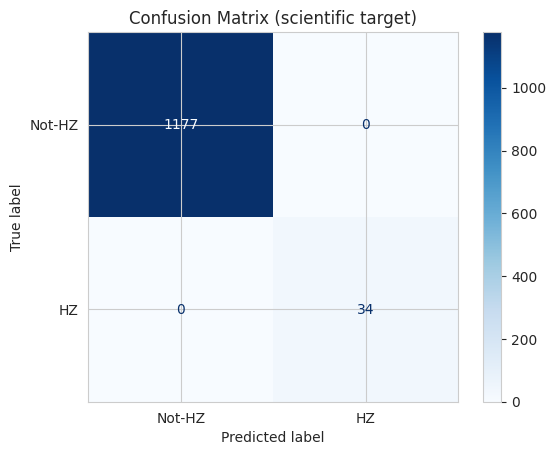

ROC AUC: 1.0000


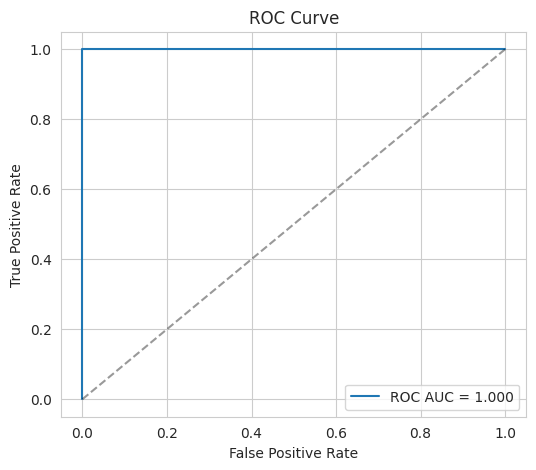

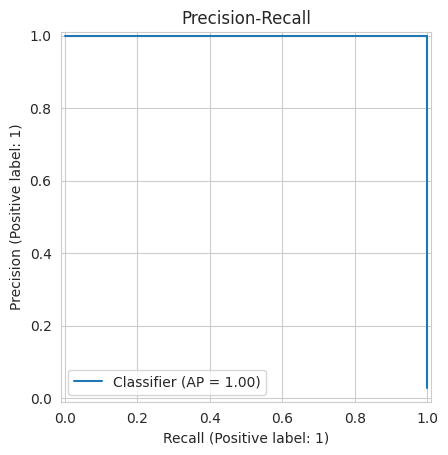

5-fold CV ROC-AUC scores: [1.     1.     0.9999 1.     1.    ]
Mean CV ROC-AUC: 1.0

Feature importances:


,0
insolation_calc,0.479953
pl_orbper,0.201043
semi_major_axis_AU,0.156014
st_rad,0.046951
st_teff,0.039928
pl_rade,0.036032
st_mass,0.027623
pl_masse,0.012456


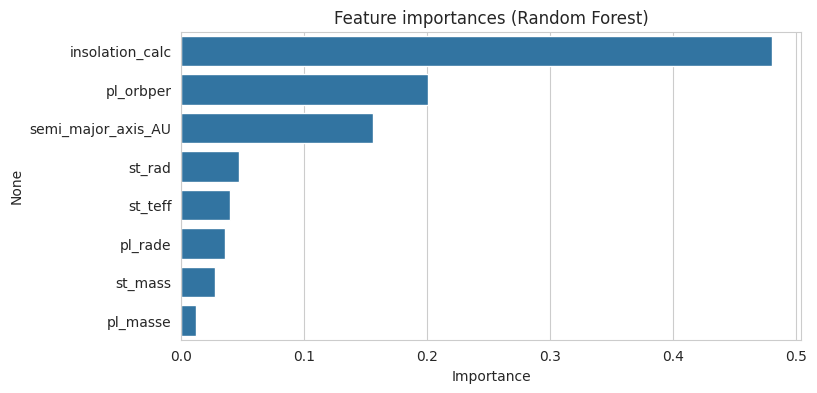

Saved trained model and preprocessors to /content/hz_rf_model.pkl

Sample false negatives (true HZ but predicted not HZ):


,pl_name,y_true,y_pred,y_proba



Sample false positives (predicted HZ but true not HZ):


,pl_name,y_true,y_pred,y_proba



Done — ML model trained on physics-based target. Use 'habitable_candidate_scientific' as your label moving forward.


In [15]:
# ============================
# ML PIPELINE using scientific target
# ============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, PrecisionRecallDisplay
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV
import pickle

sns.set_style("whitegrid")

# Safety check
if "df" not in globals():
    raise ValueError("❌ 'df' is not defined. Run the previous cells that fetch and compute HZ first.")

# 1) Choose features that are physically meaningful and likely available
feature_candidates = [
    "pl_rade", "pl_masse",           # planet physical size/mass
    "semi_major_axis_AU",            # orbital distance
    "insolation_calc",               # computed insolation (S⊕)
    "pl_orbper",                     # orbital period (days)
    "st_teff", "st_rad", "st_mass",  # stellar properties
    "pl_orbeccen"                    # eccentricity (if present)
]

# Keep only features that actually exist in dataframe
features = [c for c in feature_candidates if c in df.columns]
print("Using features:", features)

# 2) Target: scientific HZ binary
target = "habitable_candidate_scientific"
if target not in df.columns:
    raise ValueError(f"Target '{target}' not found in df. Run the HZ computation first.")

# 3) Prepare X, y; drop rows with no target info
data = df[features + [target]].copy()
data = data.dropna(subset=[target])  # target must exist
X = data[features]
y = data[target].astype(int)

print(f"Total rows available for ML: {len(data)} (positives = {int(y.sum())})")

# 4) Impute and scale
imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=features, index=X.index)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_imputed), columns=features, index=X.index)

# 5) Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print("Train/test sizes:", X_train.shape, X_test.shape)

# 6) Model: Random Forest with calibration (better probability estimates)
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
calibrated = CalibratedClassifierCV(rf, cv=5)  # Platt scaling on out-of-folds

print("\nTraining calibrated Random Forest (this may take a moment)...")
calibrated.fit(X_train, y_train)
print("Training complete.")

# 7) Predictions + probabilities
y_pred = calibrated.predict(X_test)
y_proba = calibrated.predict_proba(X_test)[:, 1]

# 8) Metrics: classification report, confusion matrix, ROC AUC
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
Disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not-HZ","HZ"])
Disp.plot(cmap="Blues")
plt.title("Confusion Matrix (scientific target)")
plt.show()

auc = roc_auc_score(y_test, y_proba)
print(f"ROC AUC: {auc:.4f}")

# Plot ROC
fpr, tpr, thr = roc_curve(y_test, y_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC AUC = {auc:.3f}')
plt.plot([0,1],[0,1],'k--', alpha=0.4)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# Precision-Recall (helpful when classes imbalanced)
disp_pr = PrecisionRecallDisplay.from_predictions(y_test, y_proba)
plt.title("Precision-Recall")
plt.show()

# 9) Cross-validated ROC-AUC (honest estimate)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(calibrated, X_scaled, y, cv=cv, scoring="roc_auc", n_jobs=-1)
print("5-fold CV ROC-AUC scores:", np.round(cv_scores, 4))
print("Mean CV ROC-AUC:", np.round(cv_scores.mean(), 4))

# 10) Feature importances from underlying RF (calibrated wraps RF: access .base_estimator_)
rf_impl = calibrated.base_estimator if hasattr(calibrated, "base_estimator") else calibrated
# If CalibratedClassifierCV wraps an estimator and doesn't expose feature_importances_, attempt to get it:
try:
    feat_imp = rf_impl.feature_importances_
except Exception:
    # Fallback: re-train a plain RF for importances
    rf_plain = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
    rf_plain.fit(X_train, y_train)
    feat_imp = rf_plain.feature_importances_

feat_imp_series = pd.Series(feat_imp, index=features).sort_values(ascending=False)
print("\nFeature importances:")
display(feat_imp_series)

plt.figure(figsize=(8,4))
sns.barplot(x=feat_imp_series.values, y=feat_imp_series.index)
plt.title("Feature importances (Random Forest)")
plt.xlabel("Importance")
plt.show()

# 11) Save model + preprocessing for later use (dashboard)
model_artifact = {
    "model": calibrated,
    "imputer": imputer,
    "scaler": scaler,
    "features": features
}
with open("/content/hz_rf_model.pkl", "wb") as f:
    pickle.dump(model_artifact, f)
print("Saved trained model and preprocessors to /content/hz_rf_model.pkl")

# 12) Quick inspection: show top false positives and false negatives to understand mistakes
test_index = X_test.index
res_df = pd.DataFrame({
    "pl_name": data.loc[test_index].get("pl_name", test_index),
    "y_true": y_test,
    "y_pred": y_pred,
    "y_proba": y_proba
}, index=test_index)

fn = res_df[(res_df["y_true"] == 1) & (res_df["y_pred"] == 0)].sort_values("y_proba", ascending=False).head(10)
fp = res_df[(res_df["y_true"] == 0) & (res_df["y_pred"] == 1)].sort_values("y_proba", ascending=False).head(10)

print("\nSample false negatives (true HZ but predicted not HZ):")
display(fn)
print("\nSample false positives (predicted HZ but true not HZ):")
display(fp)

# Final note
print("\nDone — ML model trained on physics-based target. Use 'habitable_candidate_scientific' as your label moving forward.")

Computing permutation importance...


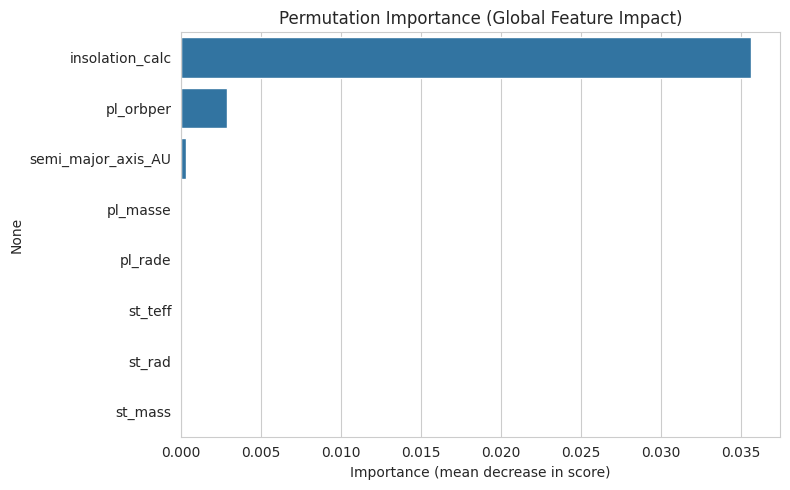

Top 3 features: ['insolation_calc', 'pl_orbper', 'semi_major_axis_AU']


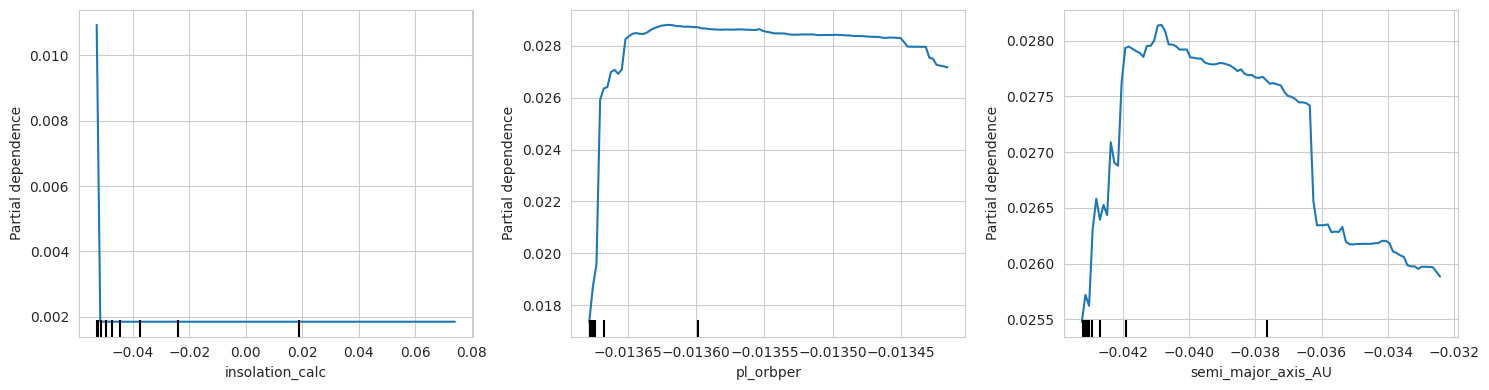

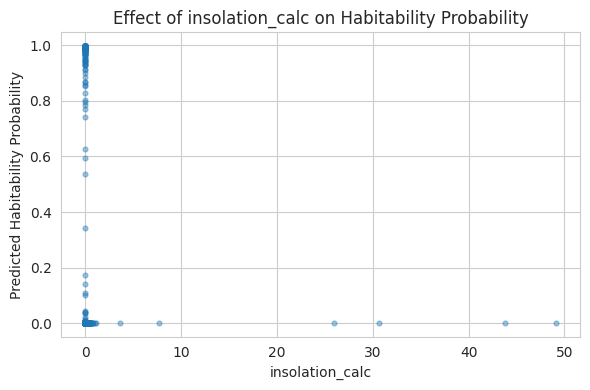

In [16]:
# === OFFLINE EXPLAINABILITY: PERMUTATION IMPORTANCE + PDP ===
# (No SHAP needed. Works 100%.)
import os, pickle, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
sns.set_style("whitegrid")

model_path = "/content/hz_rf_model.pkl"
if not os.path.exists(model_path):
    raise FileNotFoundError("Model file not found. Re-run your ML training cell first.")

with open(model_path, "rb") as f:
    art = pickle.load(f)

model = art["model"]
imputer = art["imputer"]
scaler  = art["scaler"]
features = art["features"]

# Prepare data
X = df[features].copy()
X_imp = pd.DataFrame(imputer.transform(X), columns=features, index=X.index)
X_scaled = pd.DataFrame(scaler.transform(X_imp), columns=features, index=X.index)
y = df["habitable_candidate_scientific"]

# Sample for faster explainability
X_sub = X_scaled.sample(min(2000, len(X_scaled)), random_state=42)
y_sub = y.loc[X_sub.index]

print("Computing permutation importance...")
r = permutation_importance(model, X_sub, y_sub, n_repeats=20, random_state=42, n_jobs=-1)

imp_df = pd.Series(r.importances_mean, index=features).sort_values(ascending=False)

# Plot global importance
plt.figure(figsize=(8,5))
sns.barplot(x=imp_df.values, y=imp_df.index)
plt.title("Permutation Importance (Global Feature Impact)")
plt.xlabel("Importance (mean decrease in score)")
plt.tight_layout(); plt.show()

# Partial Dependence for top 3 features
top3 = list(imp_df.index[:3])
print("Top 3 features:", top3)

fig, ax = plt.subplots(1, len(top3), figsize=(5*len(top3),4))
for i, feat in enumerate(top3):
    PartialDependenceDisplay.from_estimator(model, X_scaled, [feat], ax=ax[i], kind="average")

plt.tight_layout()
plt.show()

# Probability vs top feature
top = top3[0]
probs = model.predict_proba(X_scaled)[:,1]

plt.figure(figsize=(6,4))
plt.scatter(X_scaled[top], probs, s=12, alpha=0.4)
plt.xlabel(top)
plt.ylabel("Predicted Habitability Probability")
plt.title(f"Effect of {top} on Habitability Probability")
plt.tight_layout(); plt.show()

In [22]:
import numpy as np
import pandas as pd

# physical constants
R_sun_m = 6.957e8         # meters
AU_m     = 1.495978707e11 # meters

# albedo variations
A_default = 0.3
A_optimistic = 0.1

# Ensure columns exist and are numeric
for col in ["semi_major_axis_AU","st_rad","st_teff","pl_masse","pl_rade","insolation_calc"]:
    if col not in df.columns:
        df[col] = np.nan

df["st_rad"] = pd.to_numeric(df["st_rad"], errors="coerce")
df["st_teff"] = pd.to_numeric(df["st_teff"], errors="coerce")
df["semi_major_axis_AU"] = pd.to_numeric(df["semi_major_axis_AU"], errors="coerce")
df["pl_masse"] = pd.to_numeric(df["pl_masse"], errors="coerce")
df["pl_rade"] = pd.to_numeric(df["pl_rade"], errors="coerce")

# ------------------------
# Correct Equilibrium Temperature
# ------------------------
def compute_Teq(row, A=A_default):
    try:
        Tstar = row["st_teff"]
        Rstar_m = row["st_rad"] * R_sun_m
        a_m = row["semi_major_axis_AU"] * AU_m
        if pd.isna(Tstar) or pd.isna(Rstar_m) or pd.isna(a_m) or a_m <= 0:
            return np.nan
        return Tstar * np.sqrt(Rstar_m / (2.0 * a_m)) * (1 - A)**0.25
    except:
        return np.nan

df["Teq_K_correct"] = df.apply(lambda r: compute_Teq(r, A=A_default), axis=1)
df["Teq_K_opt"] = df.apply(lambda r: compute_Teq(r, A=A_optimistic), axis=1)

# ------------------------
# Temperature Score
# ------------------------
def temp_score(Teq):
    if pd.isna(Teq):
        return np.nan
    if Teq < 150:
        return 0.1
    if Teq > 600:
        return 0.0
    if 250 <= Teq <= 350:
        return 1.0
    if Teq < 250:
        return (Teq - 150) / 100 * 0.9 + 0.1
    return max(0.0, 1.0 - (Teq - 350) / 250)

df["temperature_score_correct"] = df["Teq_K_correct"].apply(temp_score)

# ------------------------
# Density & Score
# ------------------------
df["planet_density"] = np.where(
    (df["pl_masse"] > 0) & (df["pl_rade"] > 0),
    df["pl_masse"] / (df["pl_rade"] ** 3),
    np.nan
)

def density_score(d):
    if pd.isna(d):
        return np.nan
    if d < 1.0:
        return 0.2
    if d > 8.0:
        return 0.1
    return float(np.exp(-((d - 4.0) ** 2) / (2 * (1.8 ** 2))))

df["density_score_correct"] = df["planet_density"].apply(density_score)

# ------------------------
# Gravity & Score
# ------------------------
df["surface_gravity"] = np.where(
    (df["pl_masse"] > 0) & (df["pl_rade"] > 0),
    df["pl_masse"] / (df["pl_rade"] ** 2),
    np.nan
)

def gravity_score(g):
    if pd.isna(g):
        return np.nan
    if g < 0.3:
        return 0.1
    if g > 5.0:
        return 0.1
    return 0.2 + (min(g,5.0) - 0.3) / (4.7) * 0.8

df["gravity_score_correct"] = df["surface_gravity"].apply(gravity_score)

# ------------------------
# Insolation Score
# ------------------------
def insolation_score_correct(S):
    if pd.isna(S):
        return np.nan
    if S <= 0.1:
        return 0.1
    if S >= 5.0:
        return 0.05
    return max(0.0, 1.0 - abs(np.log10(S)))

df["insolation_score_correct"] = df["insolation_calc"].apply(insolation_score_correct)

# ------------------------
# WLI (Water Likelihood Index)
# ------------------------
score_cols = [
    "temperature_score_correct",
    "density_score_correct",
    "insolation_score_correct",
    "gravity_score_correct"
]

df["WLI_correct"] = df[score_cols].mean(axis=1, skipna=True)
df["WLI_correct"] = df["WLI_correct"].fillna(0.0)

# ------------------------
# NEW FIXED THRESHOLD (lower for ML)
# ------------------------
df["water_candidate_correct"] = (df["WLI_correct"] >= 0.30).astype(int)

print("Water candidates (new corrected WLI, threshold=0.30):", df["water_candidate_correct"].sum())

print(df[[
    "pl_name","WLI_correct","water_candidate_correct",
    "Teq_K_correct","planet_density","surface_gravity"
]].head(10))

Water candidates (new corrected WLI, threshold=0.30): 1167
         pl_name  WLI_correct  water_candidate_correct  Teq_K_correct  \
0  Kepler-1167 b     0.062500                        0    1435.367730   
1  Kepler-1740 b     0.285610                        0     857.667626   
2  Kepler-1581 b     0.062500                        0    1124.296462   
3   Kepler-644 b     0.254537                        0    1858.454878   
4  Kepler-1752 b     0.325489                        1     419.021253   
5   Kepler-280 c     0.062500                        0    1007.732086   
6  Kepler-1208 b     0.062500                        0     640.632641   
7   Kepler-263 c     0.244253                        0     418.247476   
8    HD 136352 b     0.186031                        0     827.628370   
9  Kepler-1101 b     0.262257                        0     400.243396   

   planet_density  surface_gravity  
0       30.986962        52.987705  
1        4.221748        14.029774  
2      302.619821       24

Training HZ model...

HZ classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1177
           1       1.00      1.00      1.00        34

    accuracy                           1.00      1211
   macro avg       1.00      1.00      1.00      1211
weighted avg       1.00      1.00      1.00      1211

HZ ROC-AUC: 1.0


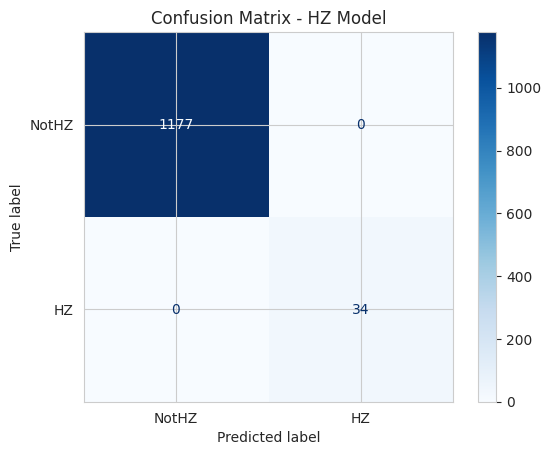


Training Water model...

Water classification report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       978
           1       0.96      0.88      0.92       233

    accuracy                           0.97      1211
   macro avg       0.97      0.94      0.95      1211
weighted avg       0.97      0.97      0.97      1211

Water ROC-AUC: 0.9923422593187463


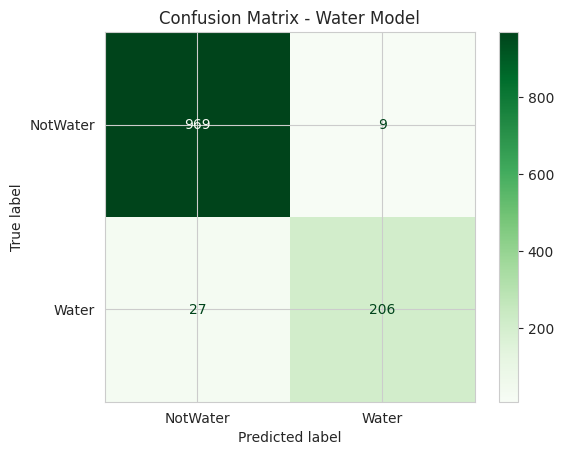


Training MultiOutputClassifier (joint model)...

MultiOutput - HZ report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1177
           1       1.00      1.00      1.00        34

    accuracy                           1.00      1211
   macro avg       1.00      1.00      1.00      1211
weighted avg       1.00      1.00      1.00      1211


MultiOutput - Water report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       978
           1       0.97      0.88      0.92       233

    accuracy                           0.97      1211
   macro avg       0.97      0.94      0.95      1211
weighted avg       0.97      0.97      0.97      1211


Saved models and preprocessors to: /content/hz_water_models_artifact.pkl

Next steps / tips:
- If water positives are few, use oversampling or lower the probability threshold.
- Inspect probability rankings for best water-rich candidates.
- 

In [24]:
# ---------- Train models for HZ and Water (separate + multi-output) ----------

import os, pickle, numpy as np, pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt, seaborn as sns
sns.set_style("whitegrid")

# ----- Config -----
RANDOM_STATE = 42
MODEL_DIR = "/content"
os.makedirs(MODEL_DIR, exist_ok=True)

# ----- Prepare features X and two targets y_hz, y_water -----
features = ["pl_rade","pl_masse","semi_major_axis_AU","insolation_calc",
            "pl_orbper","st_teff","st_rad","st_mass","WLI"]

for c in features:
    if c not in df.columns:
        df[c] = np.nan

X = df[features].copy()

# CORRECT target columns
y_hz = df["habitable_candidate_scientific"].astype(int)
y_water = df["water_candidate_correct"].astype(int)   # <<< FIXED HERE

# ----- Stratified split -----
combined_label = y_hz.astype(str) + "_" + y_water.astype(str)

X_train, X_test, y_train_hz, y_test_hz, y_train_water, y_test_water = train_test_split(
    X, y_hz, y_water,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=combined_label
)

# ----- Preprocessing -----
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_train_imp = imputer.fit_transform(X_train)
X_train_scaled = scaler.fit_transform(X_train_imp)

X_test_imp = imputer.transform(X_test)
X_test_scaled = scaler.transform(X_test_imp)

# ----- Helper: Calibrated RandomForest -----
def build_and_train_rf(Xtr, ytr):
    base = RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    model = CalibratedClassifierCV(base)
    model.fit(Xtr, ytr)
    return model

# ----- 1) Train HZ model -----
print("Training HZ model...")
hz_model = build_and_train_rf(X_train_scaled, y_train_hz)

hz_pred = hz_model.predict(X_test_scaled)
hz_proba = hz_model.predict_proba(X_test_scaled)[:,1]

print("\nHZ classification report:")
print(classification_report(y_test_hz, hz_pred, zero_division=0))
print("HZ ROC-AUC:", roc_auc_score(y_test_hz, hz_proba))

cm = confusion_matrix(y_test_hz, hz_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["NotHZ","HZ"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - HZ Model")
plt.show()

# ----- 2) Train Water model -----
print("\nTraining Water model...")
water_model = build_and_train_rf(X_train_scaled, y_train_water)

water_pred = water_model.predict(X_test_scaled)
water_proba = water_model.predict_proba(X_test_scaled)[:,1]

print("\nWater classification report:")
print(classification_report(y_test_water, water_pred, zero_division=0))
print("Water ROC-AUC:", roc_auc_score(y_test_water, water_proba))

cm2 = confusion_matrix(y_test_water, water_pred)
disp2 = ConfusionMatrixDisplay(cm2, display_labels=["NotWater","Water"])
disp2.plot(cmap="Greens")
plt.title("Confusion Matrix - Water Model")
plt.show()

# ----- 3) Multi-output model -----
print("\nTraining MultiOutputClassifier (joint model)...")
base_rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

multi = MultiOutputClassifier(base_rf, n_jobs=-1)
multi.fit(X_train_scaled, np.column_stack([y_train_hz, y_train_water]))

multi_pred = multi.predict(X_test_scaled)
pred_hz_multi = multi_pred[:,0]
pred_water_multi = multi_pred[:,1]

print("\nMultiOutput - HZ report:")
print(classification_report(y_test_hz, pred_hz_multi, zero_division=0))

print("\nMultiOutput - Water report:")
print(classification_report(y_test_water, pred_water_multi, zero_division=0))

# ----- Save models -----
artifacts = {
    "imputer": imputer,
    "scaler": scaler,
    "features": features,
    "hz_model": hz_model,
    "water_model": water_model,
    "multi_model": multi
}

save_path = os.path.join(MODEL_DIR, "hz_water_models_artifact.pkl")
with open(save_path, "wb") as f:
    pickle.dump(artifacts, f)

print("\nSaved models and preprocessors to:", save_path)

print("\nNext steps / tips:")
print("- If water positives are few, use oversampling or lower the probability threshold.")
print("- Inspect probability rankings for best water-rich candidates.")
print("- Tune threshold via Precision-Recall curve for better recall.")